# Overview

This project analyzes the Student Performance dataset. The goal is to clean the data, create useful features, and visualize relationships between different factors affecting student performance.

In [29]:
import pandas as pd
import numpy as np


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv("student.csv")

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396 entries, 0 to 395
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   school      393 non-null    object 
 1   sex         393 non-null    object 
 2   age         393 non-null    float64
 3   address     393 non-null    object 
 4   famsize     393 non-null    object 
 5   Pstatus     393 non-null    object 
 6   Medu        393 non-null    float64
 7   Fedu        393 non-null    float64
 8   Mjob        393 non-null    object 
 9   Fjob        393 non-null    object 
 10  reason      393 non-null    object 
 11  guardian    393 non-null    object 
 12  traveltime  393 non-null    float64
 13  studytime   393 non-null    float64
 14  failures    393 non-null    float64
 15  schoolsup   393 non-null    object 
 16  famsup      393 non-null    object 
 17  paid        393 non-null    object 
 18  activities  393 non-null    object 
 19  nursery     393 non-null    o

In [33]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,393.000000,393.000000,393.000000,393.000000,393.000000,393.000000,393.000000,393.000000,393.000000,393.000000,393.000000,393.000000,393.000000,393.000000,393.000000,393.000000
mean,16.687023,2.753181,2.526718,1.445293,2.040712,0.335878,3.946565,3.236641,3.114504,1.473282,2.284987,3.547074,5.725191,10.916031,10.715013,10.419847
std,1.272255,1.093882,1.087932,0.694501,0.838105,0.745161,0.897670,0.998714,1.110993,0.886361,1.287778,1.389996,8.018206,3.324395,3.769535,4.592509
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


# Data Cleaning

- Loaded the dataset using pandas.
- Checked for missing values.
- Verified data types and summary statistics.

In [24]:
# Create a features
#Average marks
df["Average grade"] = (df["G1"] + df["G2"] + df["G3"])/3

#Pass/Fail
df["Pass/Fail"] = df["G3"].apply(lambda x:"Pass" if x>=10 else "Fail")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,goout,Dalc,Walc,health,absences,G1,G2,G3,Average grade,Pass/Fail
0,GP,F,18.0,U,GT3,A,4.0,4.0,at_home,teacher,...,4.0,1.0,1.0,3.0,6.0,5.0,6.0,6.0,5.666667,Fail
1,GP,F,17.0,U,GT3,T,1.0,1.0,at_home,other,...,3.0,1.0,1.0,3.0,4.0,5.0,5.0,6.0,5.333333,Fail
2,GP,F,15.0,U,LE3,T,1.0,1.0,at_home,other,...,2.0,2.0,3.0,3.0,10.0,7.0,8.0,10.0,8.333333,Pass
3,GP,F,15.0,U,GT3,T,4.0,2.0,health,services,...,2.0,1.0,1.0,5.0,2.0,15.0,14.0,15.0,14.666667,Pass
4,GP,F,16.0,U,GT3,T,3.0,3.0,other,other,...,2.0,1.0,2.0,5.0,4.0,6.0,10.0,10.0,8.666667,Pass


# Feature Engineering

Two new features were created:
- AverageGrade = Average of G1, G2, and G3.
- Pass/Fail = Pass if G3 ≥ 10, otherwise Fail.

Visulization

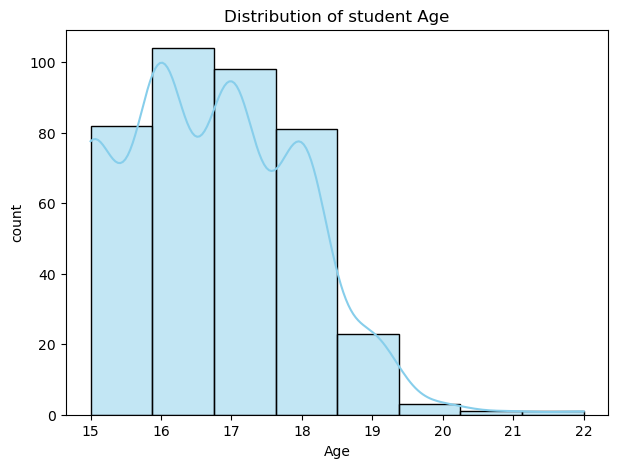

In [38]:
# Histogram

plt.figure(figsize=(7,5))
sns.histplot(df["age"], bins=8, color="skyblue", kde=True)
plt.title("Distribution of student Age")
plt.xlabel("Age")
plt.ylabel("count")
plt.show()

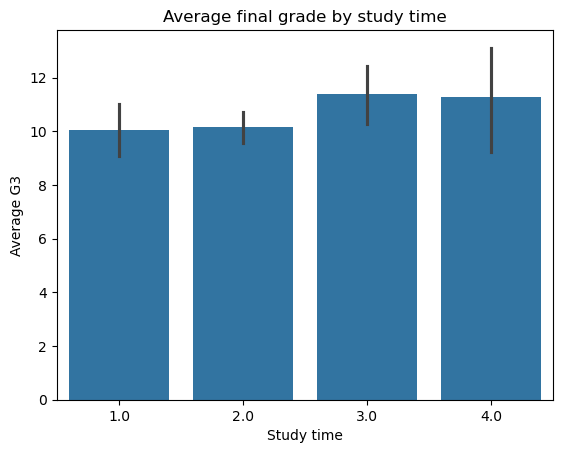

In [39]:
#Bar chart 
plt.Figure(figsize=(4,4))
sns.barplot(x="studytime", y="G3", data=df)
plt.title("Average final grade by study time")
plt.xlabel("Study time")
plt.ylabel("Average G3")
plt.show()

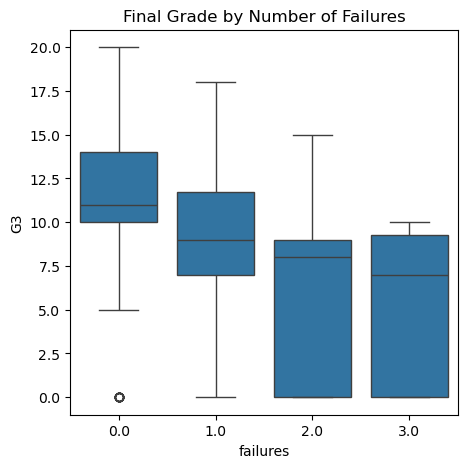

In [40]:
# Box plot
plt.figure(figsize=(5,5))
sns.boxplot(x="failures", y="G3", data=df)
plt.title("Final Grade by Number of Failures")
plt.show()

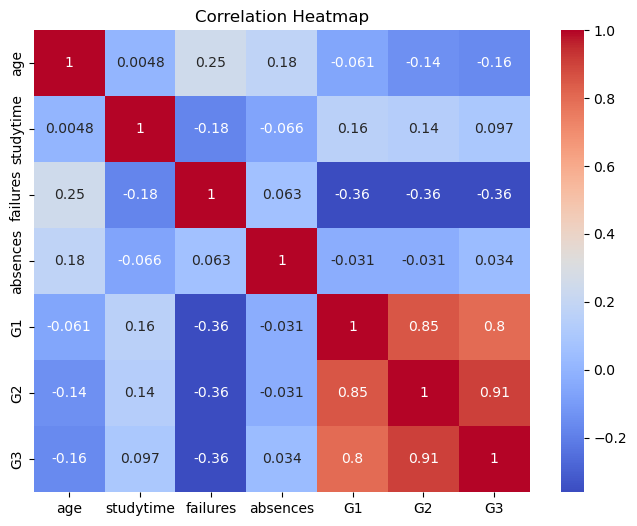

In [41]:
plt.figure(figsize=(8,6))
corr = df[["age", "studytime", "failures", "absences", "G1","G2", "G3"]].corr()
sns.heatmap(corr, annot=True,
            cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Insights

- Most students are between 16 and 18 years old.
- Students with higher study time tend to achieve better grades.
- Previous failures negatively affect final grades.
- G1 and G2 scores are strong indicators of the final grade (G3).

# Conclusion

The analysis shows that study habits and previous academic performance have a strong impact on students' final grades. Correlation analysis also indicates that G1 and G2 are closely related to G3, making them useful predictors of overall performance.